# EDA - Car Price Dataset

## 1. Import Libraries

In [5]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"]=(8,5)

## 2. Load Dataset

In [7]:
df = pd.read_csv("../data/car_price_dataset.csv")
df.head()

df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


## Dataset Information

Quan sát 5 dòng đầu tiên của dữ liệu để hiểu cấu trúc dataset.

## 3. Shape

In [8]:
print(df.shape)

(10000, 10)


## 4. Columns

In [9]:
df.columns

Index(['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission',
       'Mileage', 'Doors', 'Owner_Count', 'Price'],
      dtype='object')

## 5. Data Types

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  object 
 1   Model         10000 non-null  object 
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  object 
 5   Transmission  10000 non-null  object 
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


Qua kết quả trên có thể thấy dataset gồm các biến dạng:

- Numerical
- Categorical

Không có cột datetime.

## 6. Missing Values

In [11]:
df.isnull().sum()

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

## 7. Duplicate

In [12]:
df.duplicated().sum()

np.int64(0)

## 8. Describe

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,10000.0,2011.54370,6.897699,2000.0,2006.00,2012.0,2017.0,2023.0
Engine_Size,10000.0,3.00056,1.149324,1.0,2.00,3.0,4.0,5.0
Mileage,10000.0,149239.11180,86322.348957,25.0,74649.25,149587.0,223577.5,299947.0
Doors,10000.0,3.49710,1.110097,2.0,3.00,3.0,4.0,5.0
Owner_Count,10000.0,2.99110,1.422682,1.0,2.00,3.0,4.0,5.0
Price,10000.0,8852.96440,3112.596810,2000.0,6646.00,8858.5,11086.5,18301.0


## 9. Describe Object

In [14]:
df.describe(include="object").T

,count,unique,top,freq
Brand,10000,10,Ford,1048
Model,10000,30,Accord,365
Fuel_Type,10000,4,Electric,2625
Transmission,10000,3,Manual,3372


## Univariate Analysis

### Price Distribution

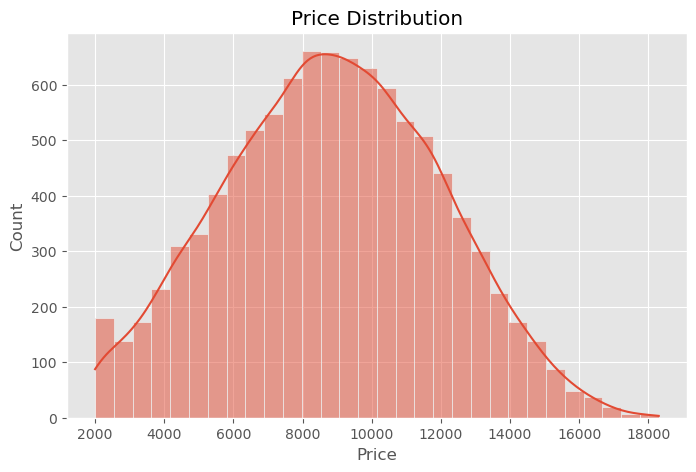

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Price"],bins=30,kde=True)

plt.title("Price Distribution")

plt.show()

**Nhận xét:** Price phân bố khá đối xứng, gần với phân phối chuẩn - giá trị trung bình (~8,853) và trung vị (~8,858) rất gần nhau. Giá dao động từ 2,000 đến 18,301, tập trung nhiều nhất ở khoảng 7,000 - 11,000, không lệch (skew) rõ rệt.

### Year Distribution

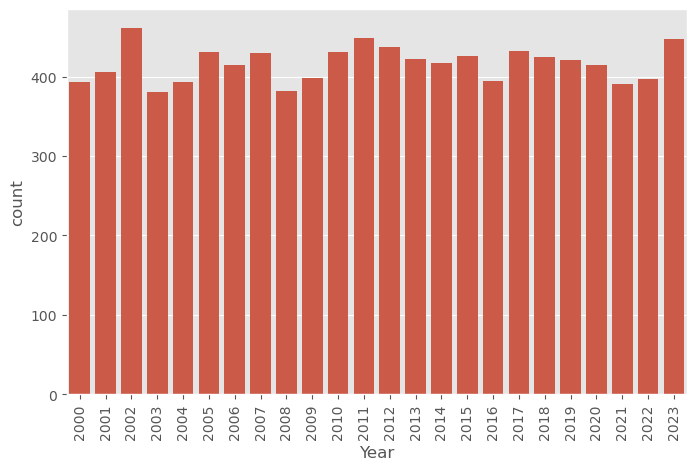

In [16]:
sns.countplot(data=df,x="Year")

plt.xticks(rotation=90)

plt.show()

**Nhận xét:** Số lượng xe theo từng Year (2000 - 2023) phân bố tương đối đồng đều giữa các năm, không tập trung dồn vào giai đoạn nào.

### Brand Distribution

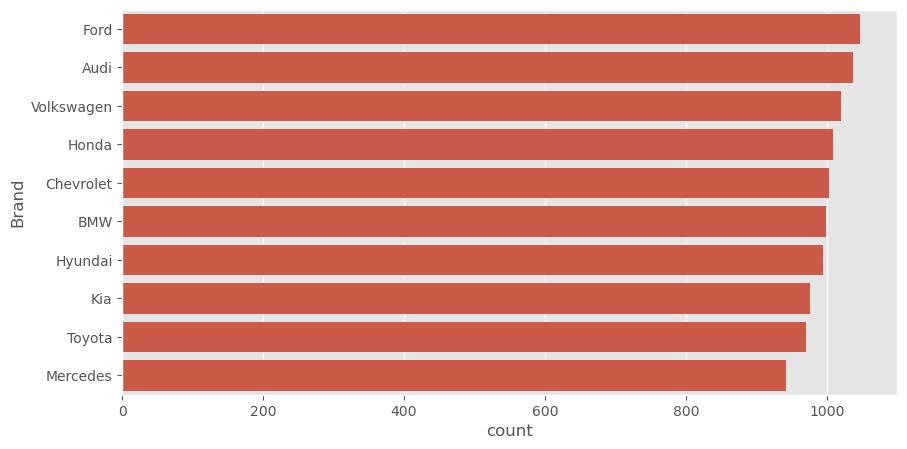

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="Brand",
    order=df.Brand.value_counts().index
)

plt.show()

**Nhận xét:** 10 Brand có số lượng mẫu khá cân bằng (942 - 1,048 mẫu/hãng), không có hãng nào chiếm ưu thế rõ rệt trong dataset.

### Model Distribution

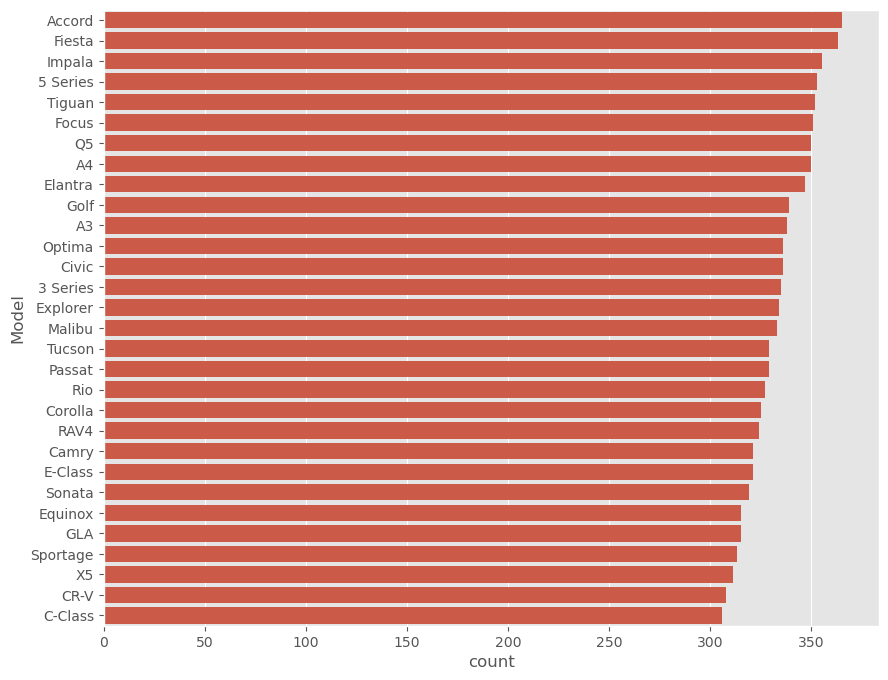

In [18]:
plt.figure(figsize=(10,8))

sns.countplot(
    data=df,
    y="Model",
    order=df.Model.value_counts().index
)

plt.show()

**Nhận xét:** Có 30 Model khác nhau, phân bố khá dàn trải, không có model nào chiếm số lượng áp đảo (model nhiều nhất - Accord - chỉ khoảng 365/10,000 mẫu).

### Fuel Type

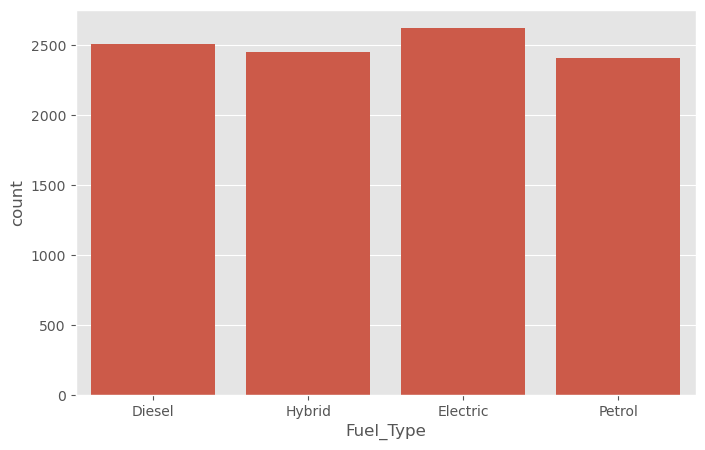

In [19]:
sns.countplot(data=df,x="Fuel_Type")

plt.show()

**Nhận xét:** 4 loại Fuel_Type (Electric, Diesel, Hybrid, Petrol) phân bố khá đồng đều, dao động từ 2,410 đến 2,625 mẫu mỗi loại.

### Transmission

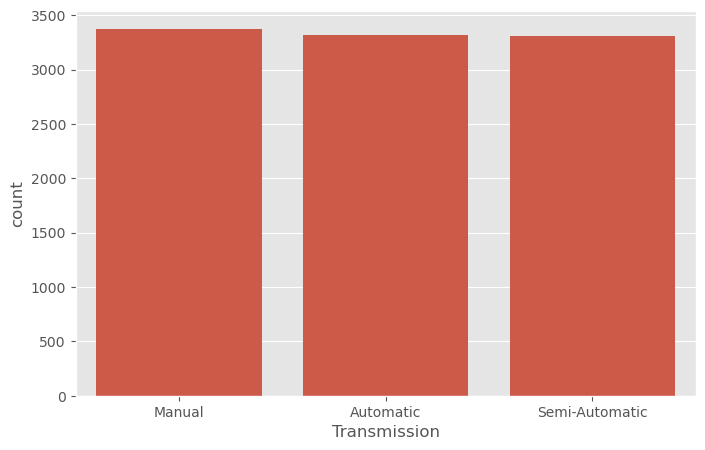

In [20]:
sns.countplot(data=df,x="Transmission")

plt.show()

**Nhận xét:** 3 loại Transmission (Manual, Automatic, Semi-Automatic) có số lượng khá cân bằng nhau (~3,300 mẫu/nhóm), không có loại nào chiếm ưu thế.

## Numerical Distribution

### Engine Size

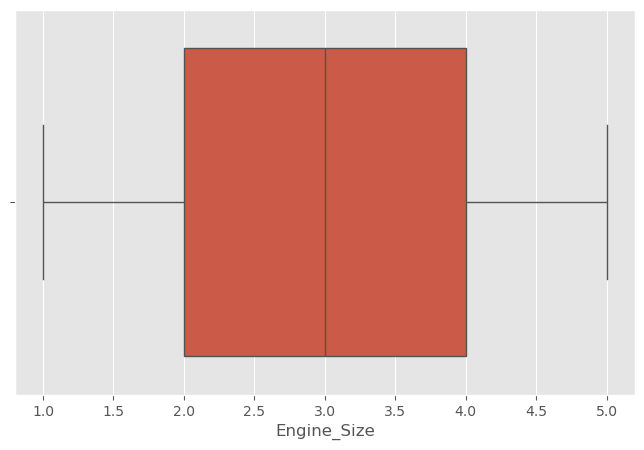

In [21]:
sns.boxplot(x=df.Engine_Size)

plt.show()

**Nhận xét:** Boxplot Engine_Size cho thấy giá trị tập trung chủ yếu trong khoảng 1.0 - 5.0, phân bố khá đều, không có outlier đáng kể.

### Mileage

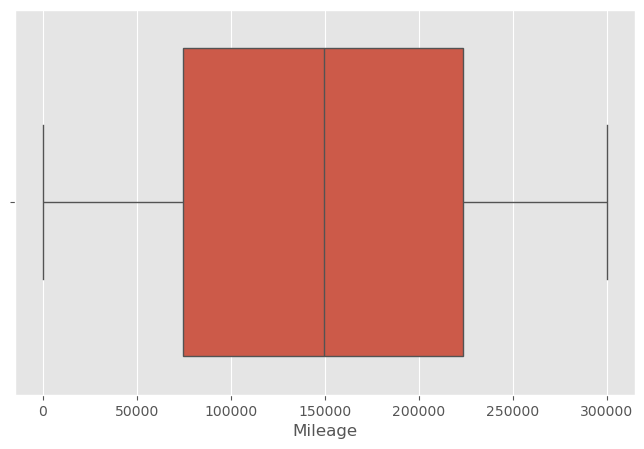

In [22]:
sns.boxplot(x=df.Mileage)

plt.show()

**Nhận xét:** Boxplot Mileage cho thấy phân bố trải khá đều từ thấp đến cao (0 - ~300,000 km), không lệch nhiều về một phía.

### Price

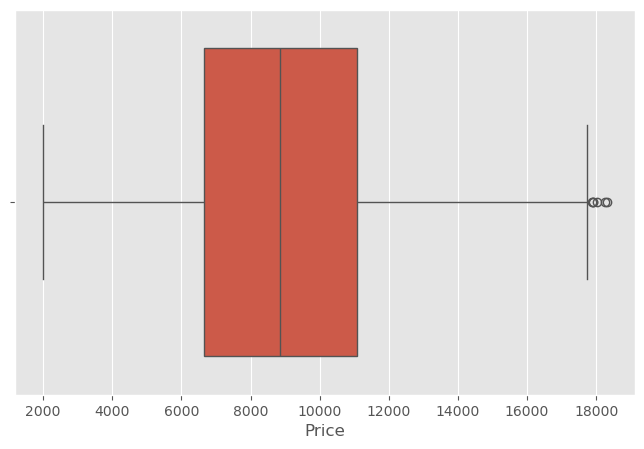

In [23]:
sns.boxplot(x=df.Price)

plt.show()

**Nhận xét:** Boxplot Price cho thấy phân bố tương đối cân đối quanh trung vị (~8,858), có một vài điểm rải rác ở hai đầu nhưng không quá cách biệt.

## Correlation

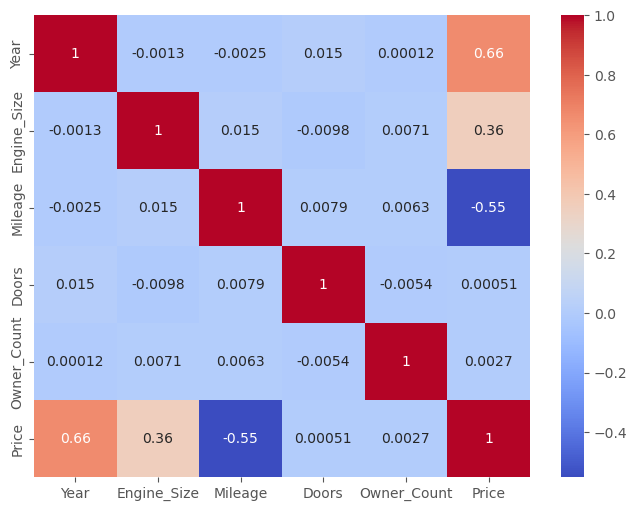

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

**Nhận xét:** Dựa trên heatmap, các hệ số tương quan đáng chú ý với Price là:

- **Year & Price: r ≈ 0.66** (tương quan dương khá mạnh) - xe đời càng mới, giá càng cao.
- **Mileage & Price: r ≈ -0.55** (tương quan âm khá mạnh) - xe đã đi càng nhiều số km, giá càng giảm.
- **Engine_Size & Price: r ≈ 0.36** (tương quan dương ở mức trung bình).
- **Doors, Owner_Count & Price: r ≈ 0** - gần như không ảnh hưởng đến giá.

=> Year và Mileage là 2 yếu tố numeric ảnh hưởng rõ rệt nhất đến Price.

## Bivariate Analysis

### Brand vs Price

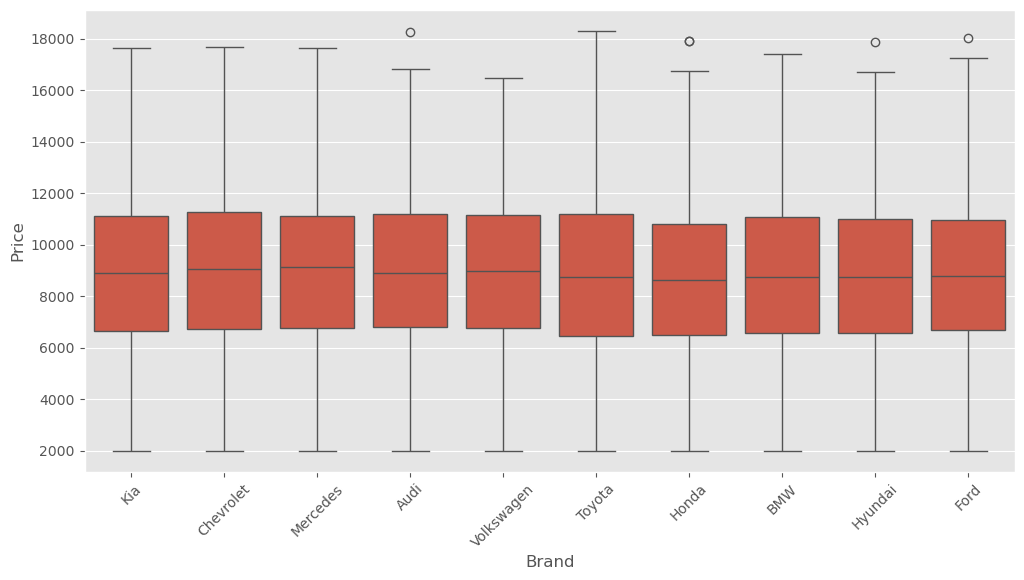

In [25]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Brand",
    y="Price"
)

plt.xticks(rotation=45)

plt.show()

**Nhận xét:** Median Price giữa các Brand khá tương đồng nhau, không có hãng nào vượt trội rõ rệt - cho thấy Brand không phải yếu tố quyết định chính đến Price trong dataset này (khác với nhận định ban đầu, ảnh hưởng của Brand là khá hạn chế).

### Fuel vs Price

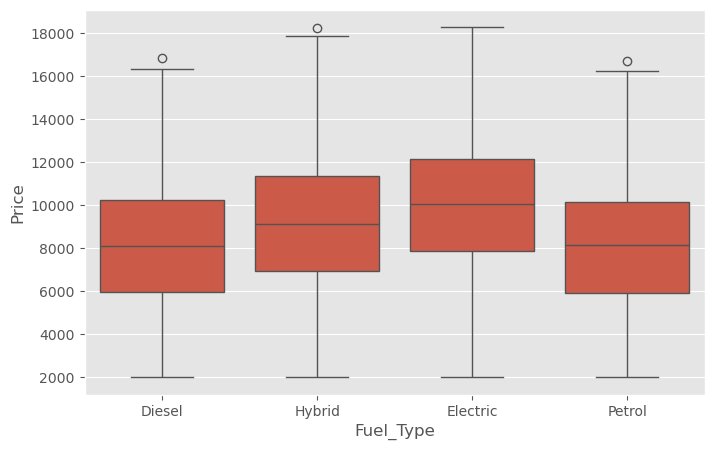

In [26]:
sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Price"
)

plt.show()

**Nhận xét:** Phân phối Price giữa các nhóm Fuel_Type (Diesel, Hybrid, Petrol, Electric) khá tương đồng nhau, không có nhóm nào vượt trội rõ rệt về giá.

### Transmission vs Price

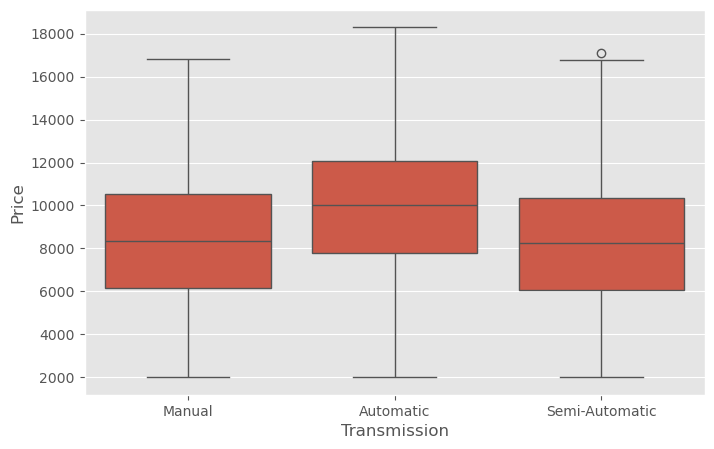

In [27]:
sns.boxplot(
    data=df,
    x="Transmission",
    y="Price"
)

plt.show()

**Nhận xét:** Phân phối Price giữa các nhóm Transmission (Manual, Automatic, Semi-Automatic) khá tương đồng nhau về median và độ trải, cho thấy Transmission không tạo ra khác biệt lớn về giá.

### Mileage vs Price

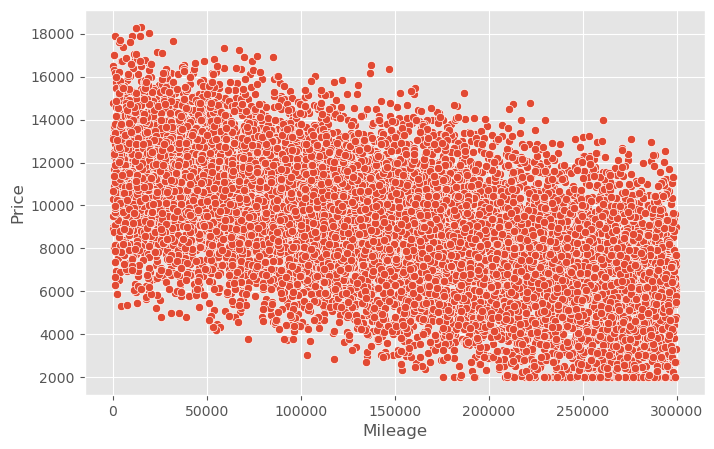

In [28]:
sns.scatterplot(
    data=df,
    x="Mileage",
    y="Price"
)

plt.show()

**Nhận xét:** Mileage và Price có xu hướng âm khá rõ - xe đi càng nhiều số km thì giá càng giảm, khớp với hệ số tương quan r ≈ -0.55 đã tính ở phần Correlation.

### Engine Size vs Price

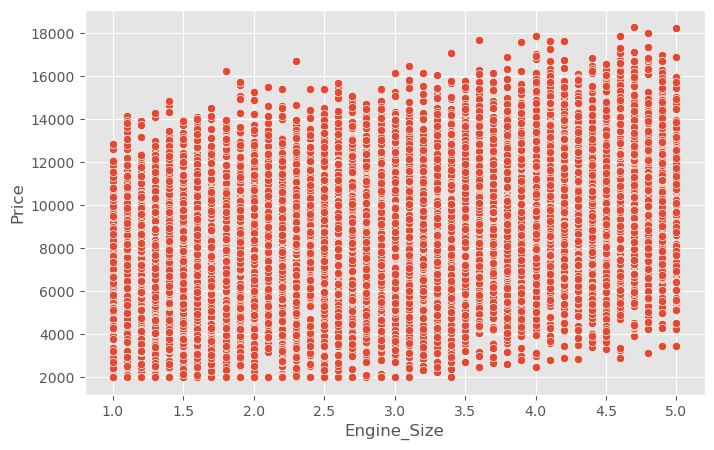

In [29]:
sns.scatterplot(
    data=df,
    x="Engine_Size",
    y="Price"
)

plt.show()

**Nhận xét:** Engine_Size và Price có xu hướng dương nhưng không quá rõ ràng (nhiều điểm phân tán), phù hợp với hệ số tương quan ở mức trung bình (r ≈ 0.36).

### Year vs Price

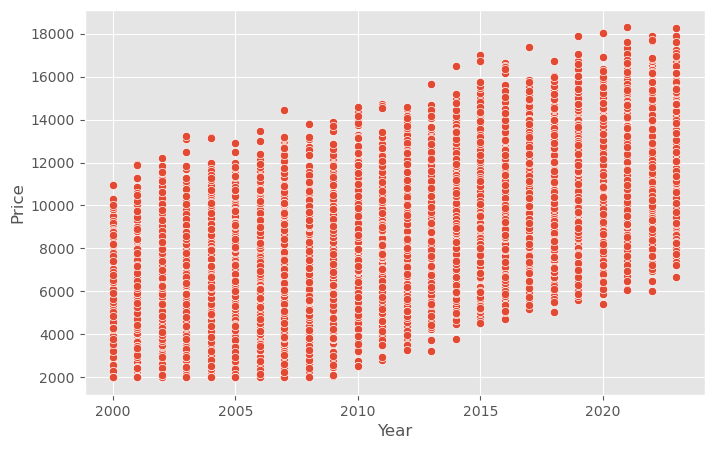

In [30]:
sns.scatterplot(
    data=df,
    x="Year",
    y="Price"
)

plt.show()

**Nhận xét:** Có xu hướng dương giữa Year và Price - xe đời càng mới, giá có xu hướng càng cao, khớp với hệ số tương quan r ≈ 0.66 đã tính ở phần Correlation.

### Pairplot

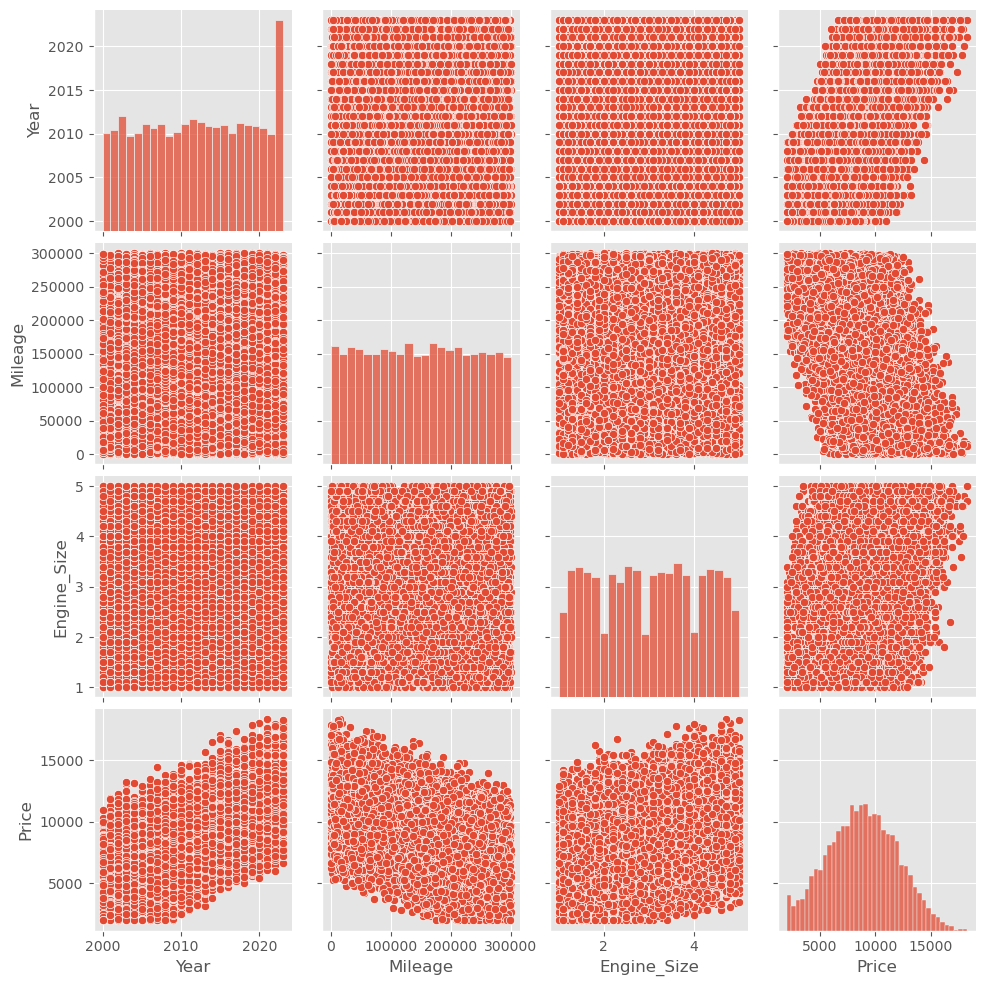

In [31]:
sns.pairplot(
    df[
        [
            "Year",
            "Mileage",
            "Engine_Size",
            "Price"
        ]
    ]
)

plt.show()

**Nhận xét:** Pairplot cho thấy rõ xu hướng: Price tăng dần theo Year, giảm dần theo Mileage - khớp với hệ số tương quan đã tính ở phần Correlation. Riêng Engine_Size không cho thấy quan hệ tuyến tính rõ ràng với Year hay Mileage.

## Outlier

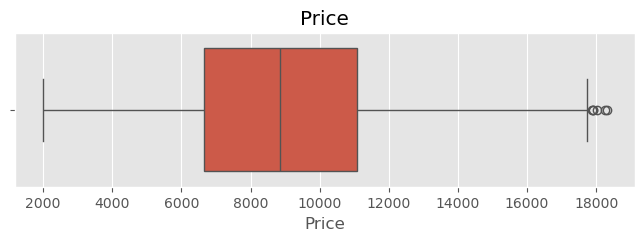

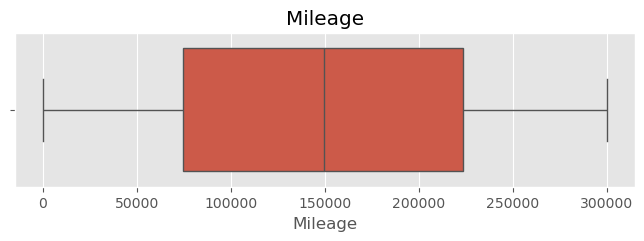

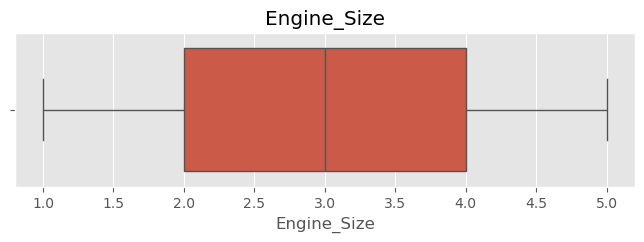

In [32]:
cols=[
    "Price",
    "Mileage",
    "Engine_Size"
]

for col in cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

**Nhận xét:** Boxplot của Price và Mileage cho thấy một vài điểm nằm ngoài khoảng whisker (outlier nhẹ), còn Engine_Size gần như không có outlier đáng kể. Nhìn chung các outlier này không quá nghiêm trọng, chưa cần xử lý đặc biệt (loại bỏ/capping) ở bước tiền xử lý.

## Category Summary

In [33]:
for col in [
    "Brand",
    "Fuel_Type",
    "Transmission"
]:

    display(
        df[col].value_counts()
    )

Brand
Ford          1048
Audi          1038
Volkswagen    1020
Honda         1009
Chevrolet     1003
BMW            999
Hyundai        995
Kia            976
Toyota         970
Mercedes       942
Name: count, dtype: int64

Fuel_Type
Electric    2625
Diesel      2512
Hybrid      2453
Petrol      2410
Name: count, dtype: int64

Transmission
Manual            3372
Automatic         3317
Semi-Automatic    3311
Name: count, dtype: int64

**Nhận xét:** Số lượng mẫu khá cân bằng giữa các nhóm: 10 Brand dao động 942 - 1,048 mẫu, 4 Fuel_Type dao động 2,410 - 2,625 mẫu, 3 Transmission dao động 3,311 - 3,372 mẫu. Không có nhóm nào chiếm ưu thế áp đảo, thuận lợi cho việc so sánh/mô hình hóa sau này.

## Numerical Summary

In [34]:
for col in [
    "Year",
    "Mileage",
    "Engine_Size",
    "Price"
]:

    print("="*40)

    print(col)

    print(df[col].describe())

Year
count    10000.000000
mean      2011.543700
std          6.897699
min       2000.000000
25%       2006.000000
50%       2012.000000
75%       2017.000000
max       2023.000000
Name: Year, dtype: float64
Mileage
count     10000.000000
mean     149239.111800
std       86322.348957
min          25.000000
25%       74649.250000
50%      149587.000000
75%      223577.500000
max      299947.000000
Name: Mileage, dtype: float64
Engine_Size
count    10000.000000
mean         3.000560
std          1.149324
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Engine_Size, dtype: float64
Price
count    10000.00000
mean      8852.96440
std       3112.59681
min       2000.00000
25%       6646.00000
50%       8858.50000
75%      11086.50000
max      18301.00000
Name: Price, dtype: float64


**Nhận xét:** Số liệu thống kê khẳng định lại các quan sát trực quan ở trên - Year và Mileage trải khá đều/rộng theo thời gian sử dụng xe, Engine_Size và Price phân bố tương đối cân đối quanh giá trị trung bình.

## Conclusion

- Dataset gồm 10,000 mẫu và 10 thuộc tính, gồm cả biến numerical và categorical, không có cột datetime.
- Không tồn tại giá trị thiếu (missing values) và dữ liệu trùng lặp (duplicate).
- Price phân bố khá đối xứng, gần chuẩn (mean ~8,853 ≈ median ~8,858), dao động từ 2,000 đến 18,301.
- Year có tương quan dương khá mạnh với Price (r ≈ 0.66): xe đời mới hơn có giá cao hơn.
- Mileage có tương quan âm khá mạnh với Price (r ≈ -0.55): xe đi càng nhiều km giá càng giảm.
- Engine_Size có tương quan dương mức trung bình với Price (r ≈ 0.36).
- Doors và Owner_Count gần như không ảnh hưởng đến Price (r ≈ 0).
- Brand, Fuel_Type, Transmission phân bố khá cân bằng giữa các nhóm và giá trị Price không khác biệt nhiều giữa các nhóm này - cho thấy ảnh hưởng của chúng lên Price yếu hơn nhiều so với Year/Mileage/Engine_Size.
- Có xuất hiện một vài outlier ở Mileage và Price qua boxplot nhưng không nghiêm trọng.
- Year và Mileage nên được ưu tiên là đặc trưng (feature) quan trọng khi xây dựng mô hình dự đoán giá xe.